<p><b>230266B - Jathunwaththa J.C.R.N.</b></p>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

<h2><b>Question 01</b></h2>

In [71]:
def intensity_transform(im, breakpoints):
    # Transformation function based on the breakpoints
    transform = np.zeros(256)
    for (x1, y1), (x2, y2) in zip(breakpoints[:-1], breakpoints[1:]):
        segment = np.linspace(y1, y2, x2 - x1, endpoint=False)
        transform[x1:x2] = segment
    transform = transform.astype(np.uint8)

    # Apply the transformation to the input image
    transformed = transform[im].astype(np.uint8)

    return transformed, transform

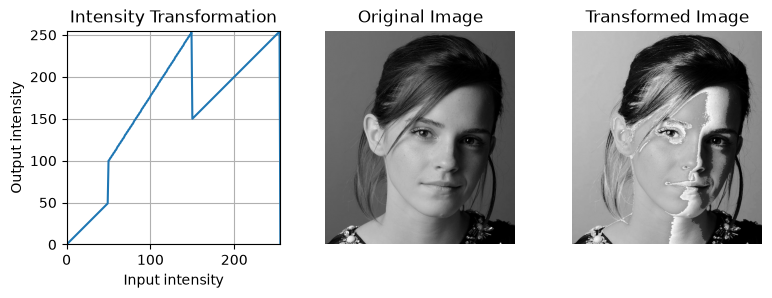

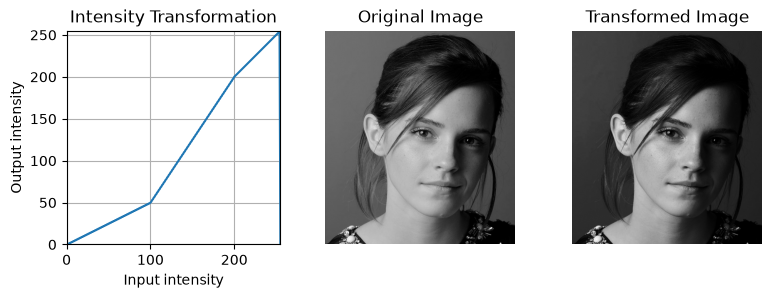

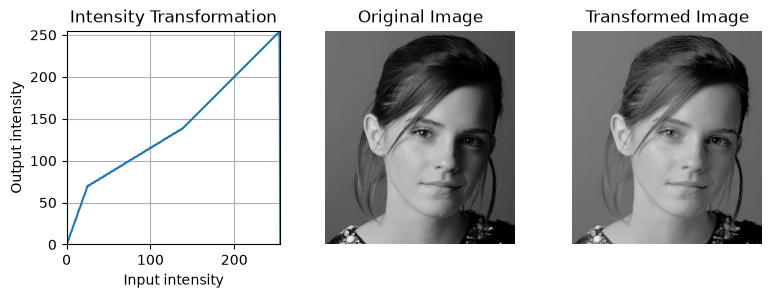

In [75]:
im = cv2.imread("../images/emma.jpeg", cv2.IMREAD_GRAYSCALE)

breakpoints_list = [
    [(0, 0), (50, 50), (50, 100), (150, 255), (150, 150), (255, 255)],
    [(0, 0), (100, 50), (200, 200), (255, 255)],
    [(0, 0), (25, 70), (140, 140), (255, 255)]
]

for breakpoints in breakpoints_list:
    transformed_im, transform = intensity_transform(im, breakpoints)
    fig, ax = plt.subplots(1, 3, figsize=(8, 2.7))

    # Transformation function
    ax[0].plot(np.arange(256), transform)
    ax[0].set_xlabel("Input intensity")
    ax[0].set_ylabel("Output intensity")
    ax[0].set_title("Intensity Transformation")
    ax[0].set_xlim(0, 255)
    ax[0].set_ylim(0, 255)
    ax[0].set_aspect("equal", adjustable="box")
    ax[0].grid()

    # Original
    ax[1].imshow(im, cmap="gray", vmin=0, vmax=255)
    ax[1].set_title("Original Image")
    ax[1].axis("off")

    # Transformed
    ax[2].imshow(transformed_im, cmap="gray", vmin=0, vmax=255)
    ax[2].set_title("Transformed Image")
    ax[2].axis("off")

    plt.tight_layout(pad=0.2)
    plt.show()

<h2><b>Question 02</b></h2>

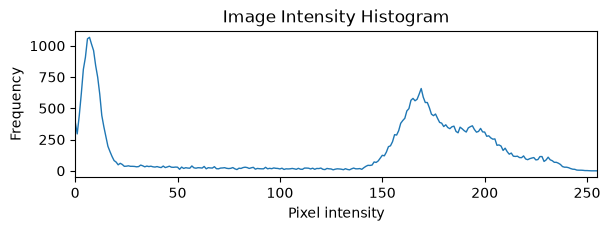

In [77]:
im = cv2.imread("../images/brain.jpeg", cv2.IMREAD_GRAYSCALE)

hist = cv2.calcHist([im], [0], None, [256], [0, 256])
fig, ax = plt.subplots(figsize=(6, 2.2))
ax.plot(hist, linewidth=1)
ax.set_xlabel("Pixel intensity")
ax.set_ylabel("Frequency")
ax.set_title("Image Intensity Histogram")
ax.set_xlim(0, 255)
plt.tight_layout(pad=0.3)
plt.show()

The intensity histogram shows that the meaningful brain tissues mainly occupy the intensity range from 160 to 220, while the background and non-target tissues have lower intensity values. In the given MRI image, the white matter appears darker than the grey matter.

Contrast enhancement using piecewise linear transformation:

- Gray matter accentuation: Intensities below 180 are mapped to 0 to suppress the background and darker tissues, while the range [180, 220] is stretched to [0, 255] to enhance the contrast of the gray matter.
- White matter accentuation: Intensities below 160 are mapped to 0 to suppress the background, while the range [160, 180] is stretched to [0, 255] to enhance and highlight the darker white matter.

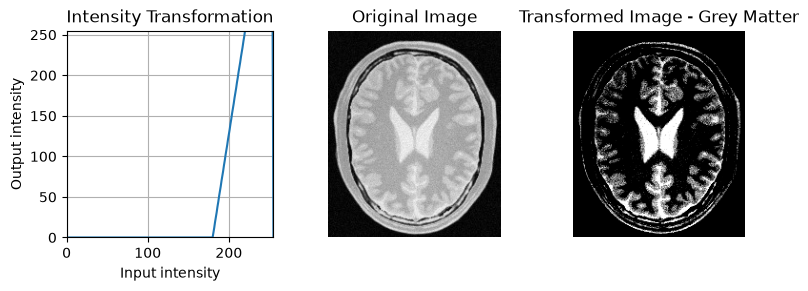

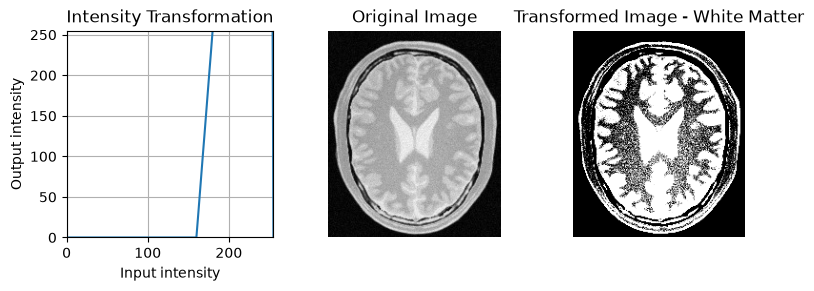

In [78]:
breakpoints_grey = [(0,   0), (180, 0), (220, 255), (255, 255)]
breakpoints_white = [(0,   0), (160, 0), (180, 255), (255, 255)]
topics = ["Grey Matter", "White Matter"]
breakpoints_list = [breakpoints_grey, breakpoints_white]

for topic, breakpoints in zip(topics, breakpoints_list):
    transformed_im, transform = intensity_transform(im, breakpoints)
    fig, ax = plt.subplots(1, 3, figsize=(8, 2.7))

    ax[0].plot(np.arange(256), transform)
    ax[0].set(xlabel="Input intensity", ylabel="Output intensity",
              title="Intensity Transformation", xlim=(0, 255), ylim=(0, 255))
    ax[0].set_aspect("equal")
    ax[0].grid()

    for a, img, title in zip(ax[1:], [im, transformed_im],
                             ["Original Image", f"Transformed Image - {topic}"]):
        a.imshow(img, cmap="gray", vmin=0, vmax=255)
        a.set_title(title)
        a.axis("off")

    plt.tight_layout(pad=0.4)
    plt.show()

<h2><b>Question 03</b></h2>

Gamma correction is applied only to the lightness ($L^*$) channel in the $L^*a^*b^*$ color space. This changes the brightness while preserving the original color information. A gamma value of $\gamma = 0.55$ was used to brighten the darker regions of the image. As seen in the histogram, the $L^*$ values shift toward higher intensities, making details in dark areas more visible. The modified $L^*$ channel is then combined with the original $a^*$ and $b^*$ channels to produce the final image while maintaining its original colors.


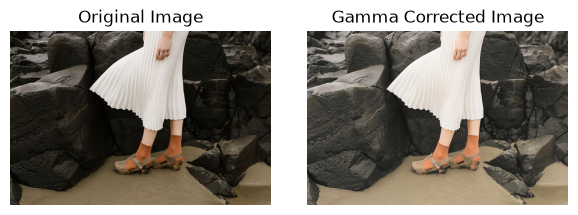

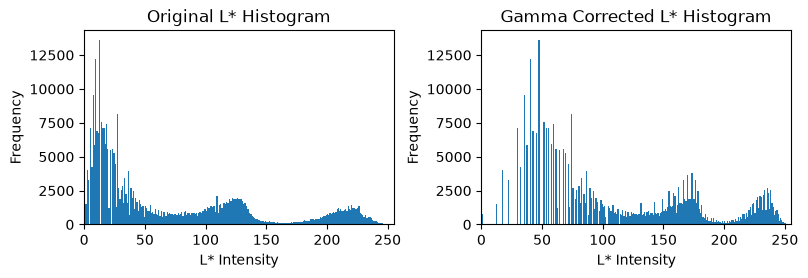

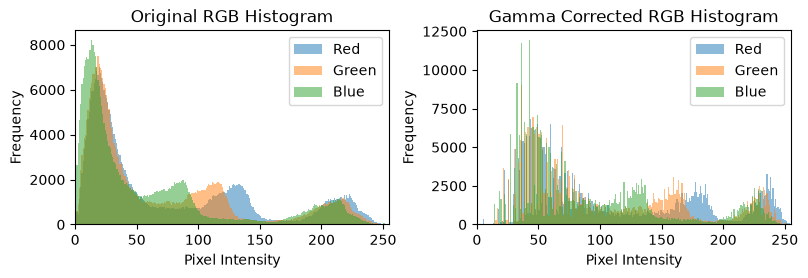

In [53]:
im = cv2.imread('../images/skirt.jpeg')

# Convert to Lab
lab = cv2.cvtColor(im, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(lab)

# Gamma correction
gamma = 0.55
L_gamma = np.power(L / 255.0, gamma) * 255.0

# Reconstruct image
lab_gamma = cv2.merge((L_gamma.astype(np.uint8), a, b))
im_gamma = cv2.cvtColor(lab_gamma, cv2.COLOR_LAB2BGR)

fig, ax = plt.subplots(1, 2, figsize=(6, 2))
for a, img, title in zip(ax, [im, im_gamma], ["Original Image", "Gamma Corrected Image"]):
    a.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    a.set_title(title, fontsize=12); a.axis("off")
plt.tight_layout(pad=0.4); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(8, 2.7))
for a, data, title in zip(ax, [L, L_gamma], ["Original L* Histogram", "Gamma Corrected L* Histogram"]):
    a.hist(data.ravel(), bins=256, range=(0, 256))
    a.set(title=title, xlabel="L* Intensity", ylabel="Frequency", xlim=(0, 255))
plt.tight_layout(pad=0.4); plt.show()

# Plot RGB histograms for original and gamma corrected images
fig, ax = plt.subplots(1, 2, figsize=(8, 2.7))

for channel, name in enumerate(["Red", "Green", "Blue"]):
    ax[0].hist(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)[:, :, channel].ravel(), bins=256, range=(0, 256), alpha=0.5, label=name)
    ax[1].hist(cv2.cvtColor(im_gamma, cv2.COLOR_BGR2RGB)[:, :, channel].ravel(), bins=256, range=(0, 256), alpha=0.5, label=name)

ax[0].set_title("Original RGB Histogram", fontsize=12)
ax[1].set_title(f"Gamma Corrected RGB Histogram", fontsize=12)

for a in ax:
    a.set_xlabel("Pixel Intensity")
    a.set_ylabel("Frequency")
    a.set_xlim(0, 255)
    a.legend()
plt.tight_layout(pad=0.4)
plt.show()

<h2><b>Question 04</b></h2>

The parameter $a$ controls the strength of the vibrance enhancement. Increasing $a$ produces more vivid colors, while decreasing $a$ results in a weaker enhancement. A value of $a = 0.7$ was selected as it provides a noticeable increase in vibrance without making the colors appear overly strong.


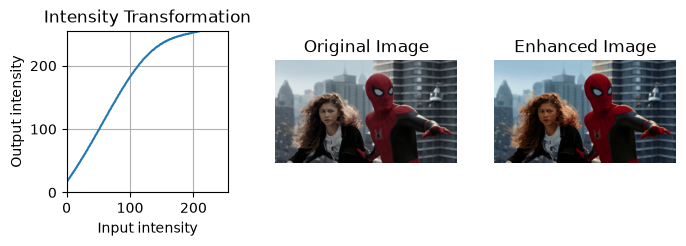

In [52]:
im = cv2.imread('../images/spiderman.jpeg')

# Convert the image to HSV color space and split the channels
hsv = cv2.cvtColor(im, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)
a = 0.7
sigma = 70

# Apply the enhancement to the saturation channel
x = np.arange(256, dtype=np.float32)
transform = np.clip(x + a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2)), 0, 255).astype(np.uint8)
s_new = cv2.LUT(s, transform)
hsv_new = cv2.merge([h, s_new, v])
im_new = cv2.cvtColor(hsv_new, cv2.COLOR_HSV2BGR)

# Display the intensity transformation, the original and enhanced images
fig, axes = plt.subplots(1, 3, figsize=(8, 2.1))

axes[0].plot(x, transform)
axes[0].set(xlabel="Input intensity", ylabel="Output intensity",
           title="Intensity Transformation", xlim=(0, 255), ylim=(0, 255))
axes[0].set_aspect("equal"); axes[0].grid()

for ax, img, title in zip(axes[1:], [im, im_new], ["Original Image", "Enhanced Image"]):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title); ax.axis("off")
plt.show()


<h2><b>Question 05</b></h2>

The original image has a narrow intensity range from 13 to 83, resulting in low contrast. After histogram equalization, the intensity values are spread over a much wider range, improving the contrast and making details more visible. The equalized histogram is more distributed across the available intensity range, although it is not perfectly uniform.


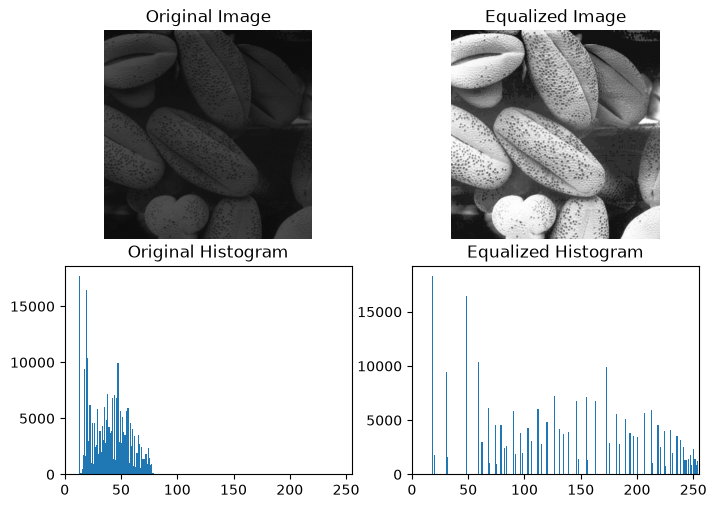

In [59]:
def histogram_equalization(im):
    # Compute the histogram of the grayscale image
    hist = np.bincount(im.ravel(), minlength=256)
    cdf = hist.cumsum()
    # Normalize the cumulative distribution function (CDF) to the range [0, 255]
    t = np.array(255 * cdf / cdf[-1], dtype=np.uint8)
    return t[im]

im = cv2.imread("../images/shells.tif", cv2.IMREAD_GRAYSCALE)
equalized_im = histogram_equalization(im)

fig, axes = plt.subplots(2, 2, figsize=(7, 5))

for ax, img, title in zip(axes[0], [im, equalized_im], ["Original Image", "Equalized Image"]):
    ax.imshow(img, vmin=0, vmax=255, cmap="gray")
    ax.set_title(title); ax.axis("off")

for ax, img, title in zip(axes[1], [im, equalized_im], ["Original Histogram", "Equalized Histogram"]):
    ax.hist(img.ravel(), bins=257, range=(0, 256))
    ax.set_xlim(0, 255); ax.set_title(title)

plt.tight_layout(pad=0.4); plt.show()

<h2><b>Question 06</b></h2>

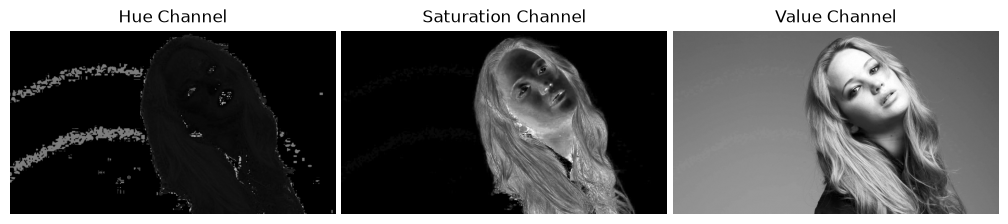

In [62]:
im = cv2.imread('../images/jennifer.jpeg')

hsv = cv2.cvtColor(im, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

fig, ax = plt.subplots(1, 3, figsize=(10, 3))
for a, ch, title in zip(ax, [h, s, v], ["Hue Channel", "Saturation Channel", "Value Channel"]):
    a.imshow(ch, cmap="gray", vmin=0, vmax=255)
    a.set_title(title); a.axis("off")

plt.tight_layout(pad=0.4); plt.show()

The Saturation ($S$) channel was selected because it provides the clearest separation between the foreground and background. The foreground has noticeably different saturation values from the background, making it easier to create a binary mask using a suitable threshold.

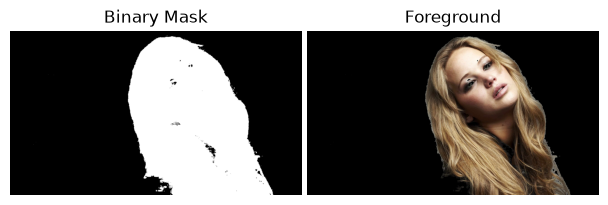

In [63]:
threshold = 13

mask = (s > threshold).astype(np.uint8) * 255
foreground = cv2.bitwise_and(im, im, mask=mask)

fig, axes = plt.subplots(1, 2, figsize=(6, 2.5))
axes[0].imshow(mask, cmap="gray")
axes[0].set_title("Binary Mask")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(foreground, cv2.COLOR_BGR2RGB))
axes[1].set_title("Foreground")
axes[1].axis("off")

plt.tight_layout(pad=0.4)
plt.show()

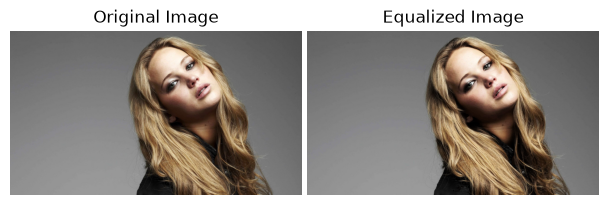

In [65]:
# Find the transformation function for histogram equalization
foreground_v = v[mask > 0]
hist = np.bincount(foreground_v.flatten(), minlength=256)
cdf = hist.cumsum()
t = np.array(255 * cdf / cdf[-1], dtype=np.uint8)

# Equalize only foreground pixels
v_result = v.copy()
v_result[mask > 0] = t[foreground_v]

hsv_result = cv2.merge([h, s, v_result])
foreground_equalized = cv2.cvtColor(hsv_result, cv2.COLOR_HSV2BGR)

# Display the original and equalized images
fig, axes = plt.subplots(1, 2, figsize=(6, 2.5))
axes[0].imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(foreground_equalized, cv2.COLOR_BGR2RGB))
axes[1].set_title('Equalized Image')
axes[1].axis('off')
plt.tight_layout(pad=0.4); plt.show()



Histogram equalization increases the contrast of the foreground by redistributing its intensity values over a wider range. In this case, the foreground appears darker, while the differences between its brighter regions become more noticeable. This improves the contrast and makes details in the brighter regions more visible.



<h2><b>Question 07</b></h2>

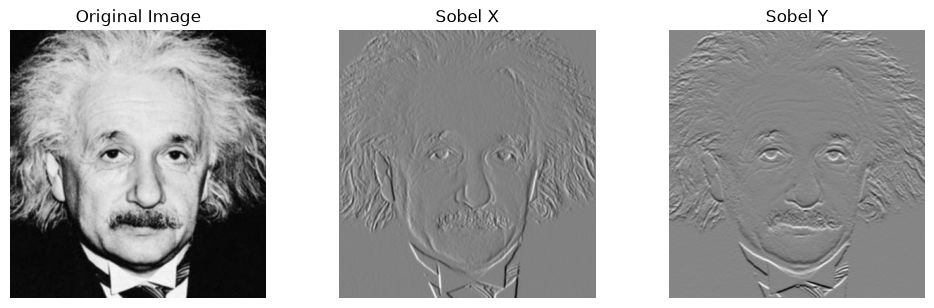

In [ ]:
im = cv2.imread('../images/einstein.jpeg', cv2.IMREAD_GRAYSCALE)

Gx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
Gy = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)

sobel_x = cv2.filter2D(im, cv2.CV_64F, Gx)
sobel_y = cv2.filter2D(im, cv2.CV_64F, Gy)

fig, ax = plt.subplots(1, 3, figsize=(10, 3))
for a, img, title in zip(ax, [im, sobel_x, sobel_y], ["Original Image", "Sobel X", "Sobel Y"]):
    a.imshow(img, cmap="gray")
    a.set_title(title); a.axis("off")

plt.tight_layout(pad=0.4); plt.show()

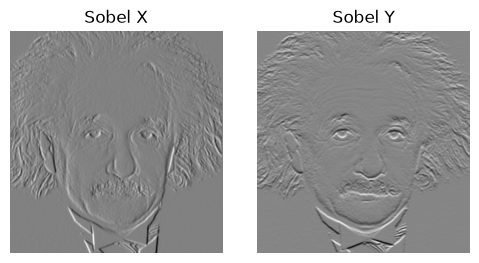

In [ ]:
# Custom implementation of 2D convolution filter for Sobel edge detection
def filter(im, kernel):
    size = kernel.shape[0]
    pad = size // 2

    im_padded = np.pad(im, pad, mode='reflect')
    output = np.zeros_like(im, dtype=np.float64)

    for i in range(im.shape[0]):
        for j in range(im.shape[1]):
            region = im_padded[i:i+size, j:j+size]
            output[i, j] = np.sum(region * kernel)

    return output

sobel_x = filter(im, Gx)
sobel_y = filter(im, Gy)

fig, ax = plt.subplots(1, 2, figsize=(5, 2.3))
ax[0].imshow(sobel_x, cmap="gray")
ax[0].set_title("Sobel X")
ax[0].axis("off")
ax[1].imshow(sobel_y, cmap="gray")
ax[1].set_title("Sobel Y")
ax[1].axis("off")

plt.tight_layout(pad=0.4)
plt.show()

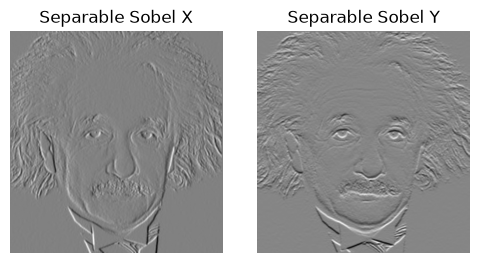

In [ ]:
# Separable Sobel x filter implementation
kx = np.array([[-1, 0, 1]], dtype=np.float64)
ky = np.array([[1], [2], [1]], dtype=np.float64)

temp = cv2.filter2D(im, cv2.CV_64F, kx)
sobel_x_separable = cv2.filter2D(temp, cv2.CV_64F, ky)

# Separable Sobel y filter implementation
kx = np.array([[1, 2, 1]], dtype=np.float64)
ky = np.array([[-1], [0], [1]], dtype=np.float64)

temp = cv2.filter2D(im, cv2.CV_64F, kx)
sobel_y_separable = cv2.filter2D(temp, cv2.CV_64F, ky)

# Display the results
fig, ax = plt.subplots(1, 2, figsize=(5, 2.3))
ax[0].imshow(sobel_x_separable, cmap="gray")
ax[0].set_title("Separable Sobel X")
ax[0].axis("off")
ax[1].imshow(sobel_y_separable, cmap="gray")
ax[1].set_title("Separable Sobel Y")
ax[1].axis("off")

plt.tight_layout(pad=0.4)
plt.show()

<h2><b>Question 08</b></h2>

Implemented scaling function:

In [56]:
def scale_image(im, s, method="nearest"):
    h, w, c = im.shape
    new_h, new_w = int(h * s), int(w * s)
    scaled_im = np.zeros((new_h, new_w, c), dtype=np.float64)

    if method == "nearest":
        for i in range(new_h):
            src_i = min(int(round(i / s)), h - 1)
            for j in range(new_w):
                src_j = min(int(round(j / s)), w - 1)
                scaled_im[i, j] = im[src_i, src_j]

    elif method == "bilinear":
        for i in range(new_h):
            x = i / s
            x0 = int(x)
            x1 = min(x0 + 1, h - 1)
            dx = 0.0 if x0 == x1 else (x - x0)

            for j in range(new_w):
                y = j / s
                y0 = int(y)
                y1 = min(y0 + 1, w - 1)
                dy = 0.0 if y0 == y1 else (y - y0)

                scaled_im[i, j] = (
                    (1 - dx) * (1 - dy) * im[x0, y0] +
                    (1 - dx) * dy       * im[x0, y1] +
                    dx       * (1 - dy) * im[x1, y0] +
                    dx       * dy       * im[x1, y1]
                )

    else:
        raise ValueError("Unsupported scaling method")

    return np.clip(np.round(scaled_im), 0, 255).astype(np.uint8)


def normalized_ssd(im1, im2):
    im1 = im1.astype(np.float64)
    im2 = im2.astype(np.float64)

    return np.sum((im1 - im2) ** 2) / np.sum(im2 ** 2)

In [57]:
small1 = cv2.imread('../images/im01small.png')
small2 = cv2.imread('../images/im02small.png')
original1 = cv2.imread('../images/im01.png')
original2 = cv2.imread('../images/im02.png')

nn1 = scale_image(small1, 4, "nearest")
bl1 = scale_image(small1, 4, "bilinear")

nn2 = scale_image(small2, 4, "nearest")
bl2 = scale_image(small2, 4, "bilinear")

print("Image 1")
print("Nearest:", normalized_ssd(nn1, original1))
print("Bilinear:", normalized_ssd(bl1, original1))

print("\nImage 2")
print("Nearest:", normalized_ssd(nn2, original2))
print("Bilinear:", normalized_ssd(bl2, original2))

Image 1
Nearest: 0.022590177565118504
Bilinear: 0.017710586711092078

Image 2
Nearest: 0.01023969256323595
Bilinear: 0.0077726702093121715


The normalized SSD was calculated for both interpolation methods after scaling the small images by a factor of 4. Bilinear interpolation resulted in a lower normalized SSD than nearest-neighbor interpolation, indicating that it produced a closer reconstruction to the original images.

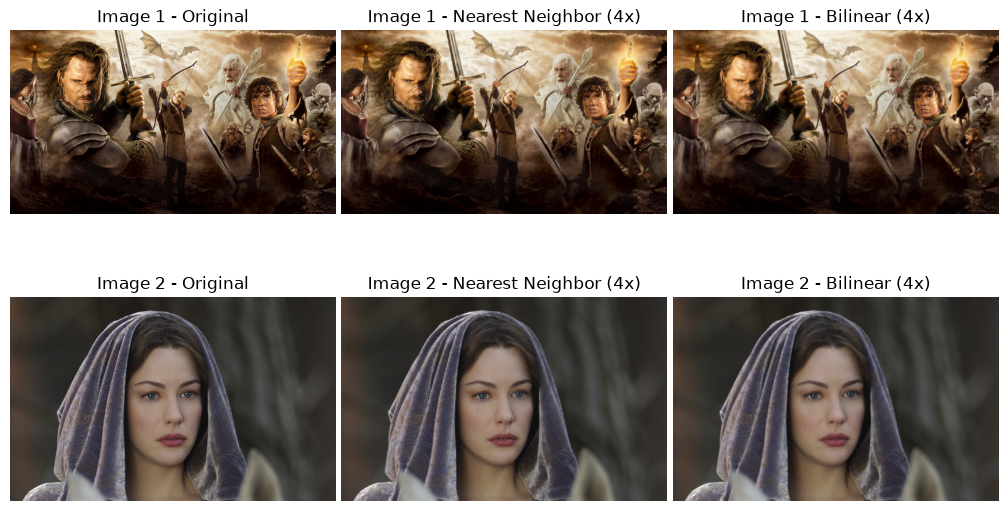

In [58]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6.2))

images = [[original1, nn1, bl1], [original2, nn2, bl2]]
methods = ["Original", "Nearest Neighbor (4x)", "Bilinear (4x)"]

for i in range(2):
    for j in range(3):
        axes[i, j].imshow(cv2.cvtColor(images[i][j], cv2.COLOR_BGR2RGB))
        axes[i, j].set_title(f"Image {i+1} - {methods[j]}")
        axes[i, j].axis("off")

plt.tight_layout(pad=0.4); plt.show()

<h2><b>Question 09</b></h2>

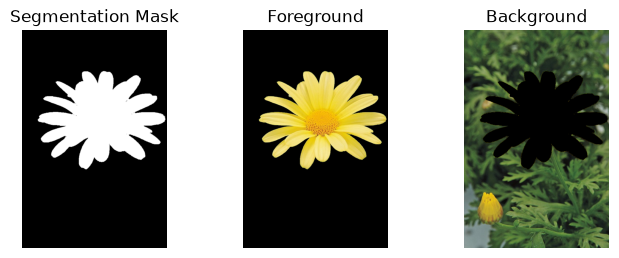

In [ ]:
im = cv2.imread('../images/flower.jpeg')
im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

mask = np.zeros(im.shape[:2], np.uint8)
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)
rect = (50, 100, 550, 490)

cv2.grabCut(im, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)
mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype("uint8")

foreground = im * mask2[:, :, np.newaxis]
background = im * (1 - mask2[:, :, np.newaxis])

fig, ax = plt.subplots(1, 3, figsize=(7, 2.5))
for a, img, title in zip(ax, [mask2, foreground, background],
                         ["Segmentation Mask", "Foreground", "Background"]):
    a.imshow(img, cmap="gray" if img is mask2 else None)
    a.set_title(title); a.axis("off")

plt.tight_layout(pad=0.4); plt.show()

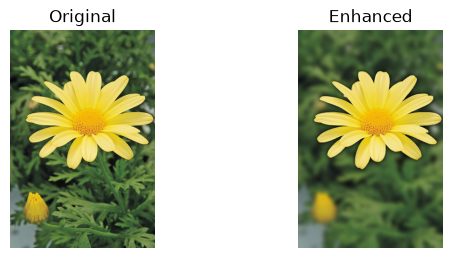

In [33]:
blurred = cv2.GaussianBlur(background, (51, 51), 0)
enhanced = foreground + blurred * (1 - mask2[:, :, np.newaxis])

fig, ax = plt.subplots(1, 2, figsize=(7, 2.5))
ax[0].imshow(im)
ax[0].set_title("Original")
ax[0].axis("off")
ax[1].imshow(enhanced)
ax[1].set_title("Enhanced")
ax[1].axis("off")

plt.tight_layout(pad=0.4)
plt.show()

The background just beyond the flower appears dark because the background image obtained from GrabCut contains black pixels where the flower was segmented. When this background is blurred, these black pixels spread into the surrounding background, creating a dark halo around the flower.

<h2><b>Question 10</b></h2>

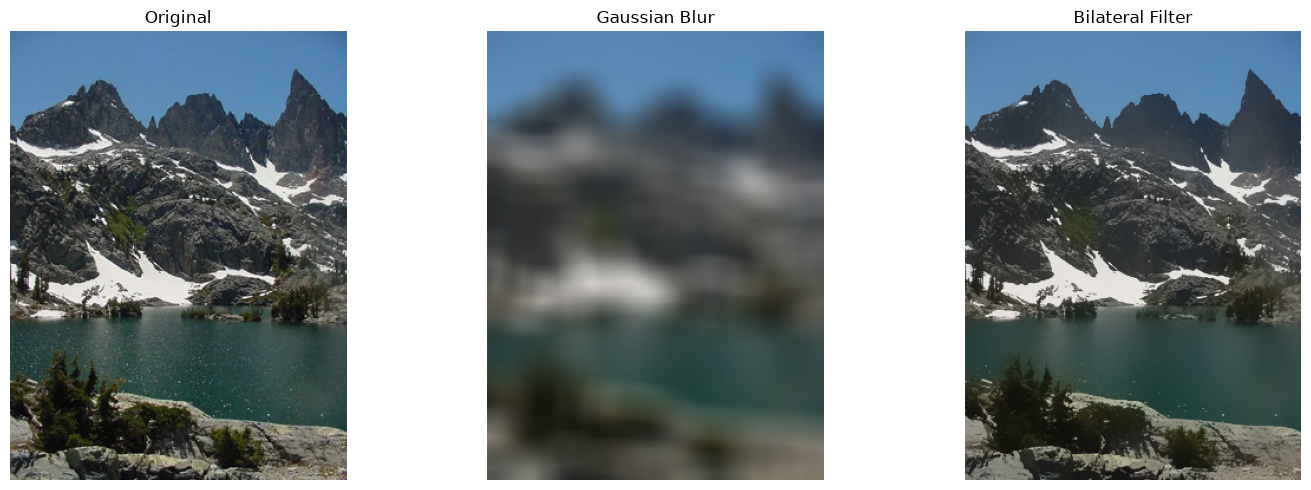

In [ ]:
im = cv2.cvtColor(cv2.imread("../images/lake.jpeg"), cv2.COLOR_BGR2RGB)

sigma_s, sigma_r = 30, 60

gaussian = cv2.GaussianBlur(im, (31, 31), sigma_s)
bilateral_cv2 = cv2.bilateralFilter(im, 31, sigma_r, sigma_s)

fig, ax = plt.subplots(1, 3, figsize=(10, 3.2))
for a, img, title in zip(ax, [im, gaussian, bilateral_cv2],
                         ["Original", "Gaussian Blur", "Bilateral Filter"]):
    a.imshow(img); a.set_title(title); a.axis("off")

plt.tight_layout(pad=0.4); plt.show()

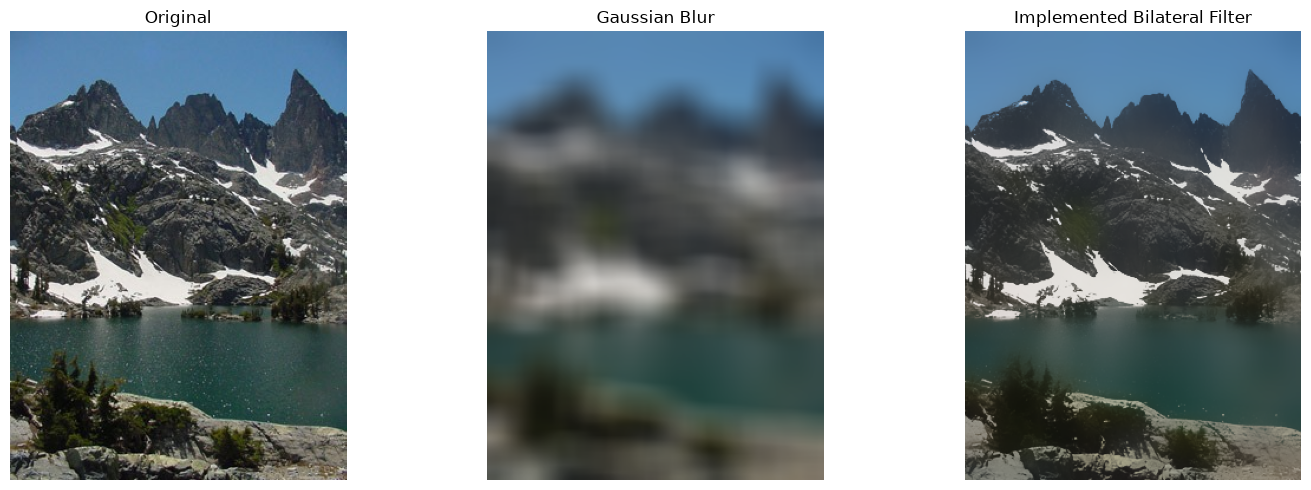

In [ ]:
def bilateral_filter(im, kernel_size, sigma_s, sigma_r):
    pad = kernel_size // 2
    padded = np.pad(
        im, ((pad, pad), (pad, pad), (0, 0)), mode="reflect"
    )

    output = np.zeros_like(im, dtype=np.float64)

    ax = np.arange(-pad, pad + 1)
    xx, yy = np.meshgrid(ax, ax)

    # G_sigma_s(||xi - x||)
    spatial = np.exp(
        -(xx**2 + yy**2) / (2 * sigma_s**2)
    )

    for x in range(im.shape[0]):
        for y in range(im.shape[1]):
            region = padded[x:x+kernel_size, y:y+kernel_size]
            center = im[x, y].astype(np.float64)

            # ||I(xi) - I(x)||
            diff = region.astype(np.float64) - center
            intensity_dist = np.sum(diff**2, axis=2)

            # G_sigma_r(||I(xi) - I(x)||)
            range_weight = np.exp(
                -intensity_dist / (2 * sigma_r**2)
            )

            weights = spatial * range_weight

            # Wp
            Wp = np.sum(weights)

            # Bilateral filter
            output[x, y] = np.sum(
                region * weights[:, :, np.newaxis],
                axis=(0, 1)
            ) / Wp

    return output.astype(np.uint8)

bilateral = bilateral_filter(im, 31, sigma_s, sigma_r)

fig, ax = plt.subplots(1, 3, figsize=(10, 3.2))
for a, img, title in zip(ax, [im, gaussian, bilateral],
                         ["Original", "Gaussian Blur", "Implemented Bilateral Filter"]):
    a.imshow(img); a.set_title(title); a.axis("off")
plt.tight_layout(pad=0.4); plt.show()

In [10]:
nssd = normalized_ssd(bilateral, bilateral_cv2)
print("Normalized SSD:", nssd)

Normalized SSD: 0.003029689769147882


The manually implemented bilateral filter produced a normalized SSD of 0.00303 compared with OpenCV's bilateral filter. The low SSD indicates that the two results are very similar, with both providing smoothing while preserving important edges.